<a href="https://colab.research.google.com/github/benjaminsheppard/Event_Review_Toolkit/blob/main/MKX_Copy_of_GR_Radar_Download.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Options Selection {"display-mode":"form"}
#@markdown Pick a start date and start time (UTC). Separate multiple dates/times by commas, in YYYY-MM-DD and HH:MM:SS format.
start_dt = "2024-05-21" #@param {type:"string"}
start_time = "22:40:00" #@param {type:"string"}
#@markdown -------
#@markdown How many hours of data do you want? Select the number of hours past the specified start time for each date/time above and separate by commas.
num_hours = '2' #@param {type:"string"}
#@markdown -------
#@markdown What radar(s) do you want data from? Select a radar for each date/time above and separate by commas.
radar = 'KMKX, KARX' #@param {type:"string"}

#@markdown Click the play (triangle) button above to set your selection.

# QC Input lengths and display a warning if applicable...
inputDelimLengths = sorted(list(set(
    [start_dt.count(","), start_time.count(","), num_hours.count(","), radar.count(",")] )))
if len(inputDelimLengths) > 1:
  if inputDelimLengths[-2] > 0:
    warningMsg  = "WARNING: Your inputs (in the dialogue boxes) have a variety of lengths, \n"
    warningMsg += "or an unnecessary comma has been detected. Generally speaking, each input \n"
    warningMsg += "to this program (start_dt, start_time, num_hours, and radar) should have \n"
    warningMsg += "the same number of entries (separated by commas) as all the other inputs, \n"
    warningMsg += "OR a single entry that applies to everything. This is just a warning, the \n"
    warningMsg += "second code block will still run if you want it to."
    print(warningMsg)

if min([len(start_dt), len(start_time), len(num_hours), len(radar)]) == 0:
  warningMsg  = "WARNING: One or more of your input fields is blank!"
  print(warningMsg)


In [ ]:
# @title Click the play (triangle) button to run the download script. Once it's finished (at least 30 seconds, depending on size of data request), proceed to instructions below to download the data. {"display-mode":"form"}
#!/usr/bin/env python2
# -*- coding: utf-8 -*-
"""
Original Author: jaretrogers
Editor / Maintainer: benjaminsheppard
"""
!pip install nexradaws

import csv
from datetime import datetime, timedelta
import tempfile
import pytz
from datetime import datetime
import nexradaws
import shutil

def equalize_listlen_via_duplication(longList,shortList):
    if len(longList)>len(shortList):
      for ix in range(0,len(longList)-len(shortList)):
        shortList.append(shortList[-1])
    return longList, shortList


def format_inputs(start_dt, start_time, num_hours, radar):
    start_dt = start_dt.replace(" ", "")
    Radar_dates = start_dt.split(',')
    start_time = start_time.replace(" ", "")
    start_time = start_time.replace(',', ', ')
    start_time = ' '+ start_time
    split_times = start_time.split(',')
    #Check if list of dates is longer than list of times
    Radar_dates, split_times = equalize_listlen_via_duplication(Radar_dates,split_times)
    #Check if list of times is longer than list of dates
    split_times, Radar_dates = equalize_listlen_via_duplication(split_times,Radar_dates)

    Radar_dates = ["{}{:02}".format(Radar_dates_, split_times_) for Radar_dates_, split_times_ in zip(Radar_dates, split_times)]
    num_hours = num_hours.replace(" ", "")
    hours_list = num_hours.split(',')
    radar = radar.replace(" ", "")
    radar_list = radar.split(',')
    return Radar_dates, hours_list, radar_list

###Download_Radar data. Pass a date list, the # of hours past the specified start time to collect data from, and the radar site.

def Download_Radar(date_list, hr_list, rad_list):
    #templocation = tempfile.mkdtemp()
    x = [datetime.strptime(s, "%Y-%m-%d %H:%M:%S") for s in date_list]
    conn = nexradaws.NexradAwsInterface()
    pacific_timezone = pytz.utc
    for i in range(0,len(x)):
        radar_id = rad_list[i]
        start = pacific_timezone.localize(x[i])
        end = start+ timedelta(hours=int(hr_list[i]))
        #end = pacific_timezone.localize (datetime(2013,5,31,19,0))
        #specify file folder in pathstr below. In this example it was in the "radar_data" folder
        pathstr = "{0:04d}".format(start.year)+'-'+"{0:02d}".format(start.month)+'-'+"{0:02d}".format(start.day)+'-'+radar_id+'-'+"{0:02d}".format(start.hour)+'Z'
        scans = conn.get_avail_scans_in_range(start, end, radar_id)
        results = conn.download(scans,pathstr)
        #print("There are {} scans available between {} and {}\n".format(len(scans), start, end))
        #print(scans[0:4])
        !zip -r /content/{pathstr}.zip /content/{pathstr}
        shutil.rmtree('/content/'+pathstr)

def check_input_lengths(Radar_dates, hours_list, radar_list):
    #Check if list of radars is longer than radar dates
    radar_list, Radar_dates = equalize_listlen_via_duplication(radar_list,Radar_dates)

    #Check if list of radars is longer than hours list
    radar_list, hours_list = equalize_listlen_via_duplication(radar_list,hours_list)

    #Check if radar dates list is longer than list of radars
    Radar_dates, radar_list = equalize_listlen_via_duplication(Radar_dates, radar_list)

    #Check if radar dates list is longer than hours list
    Radar_dates, hours_list = equalize_listlen_via_duplication(Radar_dates, hours_list)

    return Radar_dates, hours_list, radar_list


if __name__ == "__main__":
    Radar_dates, hours_list, radar_list = format_inputs(start_dt, start_time, num_hours, radar)
    Radar_dates, hours_list, radar_list = check_input_lengths(Radar_dates, hours_list, radar_list)
    Download_Radar(Radar_dates, hours_list, radar_list)
    print("All Tasks Completed! .zip file should be ready to download at this time.")

**Download the data**

Once you're finished, click on the file icon on the left hand side.

Click the three dots next to the .zip file of the date you need, and click download. Note: if you don't see the file, click the folder with a circular arrow icon above the file list to force a refresh.

Be patient as it may take up to a couple minutes to process the download. You'll know it worked when it prompts you to save it.

Large zip files featuring multiple hours of data may hang up during the download. In that case, consider smaller chunks of data for a single day.

Right click on the downloaded zip file and use the "Extract All" windows tool before opening the folder and following the subfolders to the data.

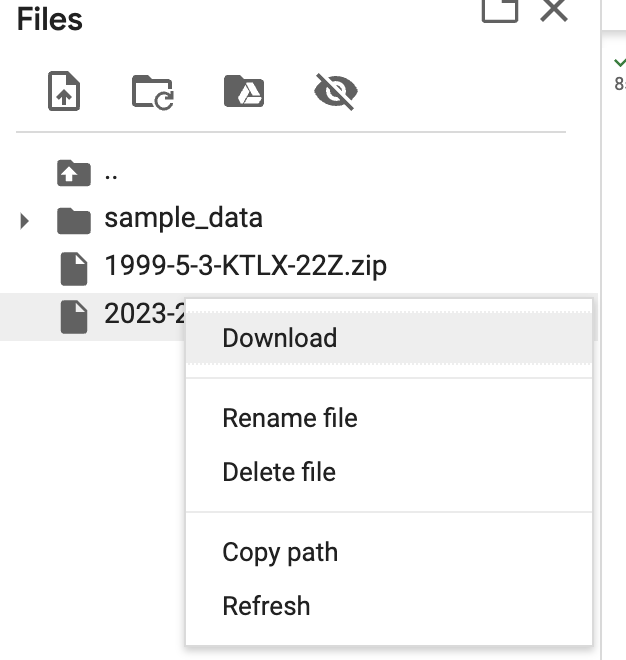